In [1]:
import pyreadstat
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score, classification_report, confusion_matrix, accuracy_score, average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

## Explanatory Data Analysis

In [ ]:
# df_ch = pyreadstat.read_sav('/kaggle/input/malnutrition/ch.sav')[0] #Kaggle dataset
df_ch = pyreadstat.read_sav('/workspaces/malnutrition/Dataset/ch.sav')[0] #GitHub Codespace dataset
# df_ch = pyreadstat.read_sav(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.sav")[0] #Local dataset


# Renaming the columns
features_rename = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = features_rename.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Remove rows with coded entries in each column
coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

df2 = df1.copy()
df2.dropna(inplace=True)

df2 = df2[~df2['child_age'].isin(coded_child_age)]
df2 = df2[~df2['underweight'].isin(coded_underweight)]
df2 = df2[~df2['stunting'].isin(coded_stunting)]
df2 = df2[~df2['wasting'].isin(coded_wasting)] 
df2 = df2[~df2['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df2 = df2[~df2['fever_last_2_weeks'].isin(coded_fever)]
df2 = df2[~df2['health_insurance'].isin(coded_insurance)]
df2 = df2[~df2['ever_breastfed'].isin(coded_breastfed)]

# Convert to Binary Response Variables
df2['underweight'] = [2 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [2 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [2 if -2 <= x < 2 else 1 for x in df2['wasting']]
df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df2 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)

# Change binary features from 1/2 to 1/0
df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']] = df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']].replace({1: 1, 2: 0})

# Standardize continuous column
scaler = StandardScaler()
df2['child_weight'] = scaler.fit_transform(df2[['child_weight']])

# One-hot encode nominal categorical column
df3 = pd.get_dummies(df2, columns=['province'], drop_first=True)

# Convert only boolean dummy columns to 0/1
cols_to_convert = df3.columns.difference(['child_weight'])
df3[cols_to_convert] = df3[cols_to_convert].astype(int)

df3.head(2)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-0.617934,1,0,0,0,1,5,0,1,1,0,0,0,0,0,0
2,2,0.797956,1,1,0,0,0,2,0,1,0,0,0,0,0,0,0


### Train-test split

In [3]:
X = df2.drop(columns=['malnurished'])
y = df2['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

# K-nearest Neighborhood

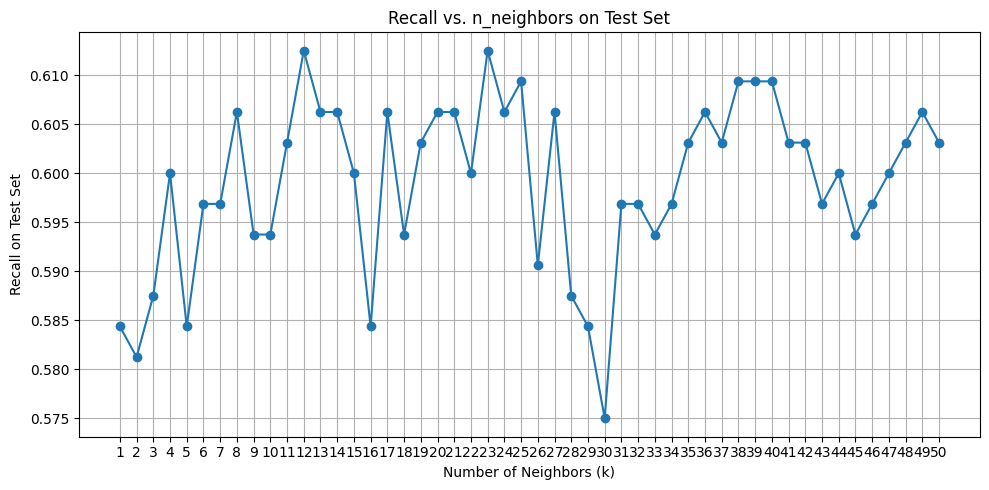

In [4]:
recalls = []

for k in range(1, 51):
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    recalls.append(recall_score(y_test, y_pred))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 51), recalls, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Recall on Test Set")
plt.title("Recall vs. n_neighbors on Test Set")
plt.grid(True)
plt.xticks(range(1, 51))
plt.tight_layout()
plt.show()

In [5]:
knn = KNeighborsClassifier(n_neighbors=23, weights='distance')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f'Confusion Matrix: \n{pd.crosstab(y_test, y_pred)}\n')
print(f'Classification Report: \n{classification_report(y_test, y_pred)}\n')

Confusion Matrix: 
col_0          0    1
malnurished          
0            259  138
1            124  196

Classification Report: 
              precision    recall  f1-score   support

           0       0.68      0.65      0.66       397
           1       0.59      0.61      0.60       320

    accuracy                           0.63       717
   macro avg       0.63      0.63      0.63       717
weighted avg       0.64      0.63      0.64       717




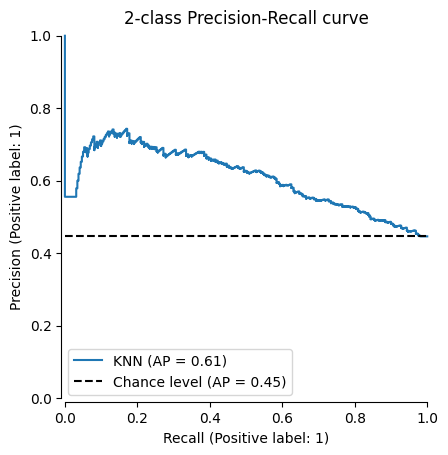

In [6]:
display = PrecisionRecallDisplay.from_estimator(
    knn,                  # trained model
    X_test,        # Test features
    y_test,               # True labels
    name="KNN",
    plot_chance_level=True,
    despine=True
)
display.ax_.set_title("2-class Precision-Recall curve")
plt.show()

# Hyperparameter Tuning

In [7]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
params = {'n_neighbors':range(1, 36), 
          'weights':['uniform', 'distance'], 
          'p':[1,2]}

knn = KNeighborsClassifier()
cv = StratifiedKFold(n_splits=20, shuffle=True, random_state=42)
knn_grid_cv = GridSearchCV(knn, 
                           param_grid=params, 
                           scoring='recall', 
                           cv=cv
                           ) 
knn_grid_cv.fit(X_train, y_train)

print("Best CV Recall Score:", knn_grid_cv.best_score_)
print("Best Estimator:", knn_grid_cv.best_estimator_)

Best CV Recall Score: 0.5540426587301587
Best Estimator: KNeighborsClassifier(n_neighbors=4, weights='distance')


In [8]:
y_pred_tunned = knn_grid_cv.predict(X_test)
print(f'Classification Report: \n{classification_report(y_test, y_pred_tunned)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.67      0.65      0.66       397
           1       0.58      0.60      0.59       320

    accuracy                           0.63       717
   macro avg       0.63      0.63      0.63       717
weighted avg       0.63      0.63      0.63       717




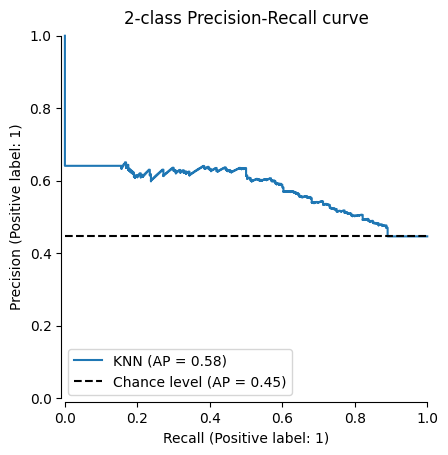

In [9]:
display = PrecisionRecallDisplay.from_estimator(
    knn_grid_cv,   # trained model
    X_test,        # Test features
    y_test,        # True labels
    name="KNN",
    plot_chance_level=True,
    despine=True
)
display.ax_.set_title("2-class Precision-Recall curve")
plt.show()